# Matrix Inversion with Quantum Singular Value Transform (QSVT)

> **Quantum Matrix Inversion (or Quantum Linear Solver) via QSVT** provides a framework for solving linear systems exponentially faster than known classical methods under certain conditions [\[1\]](#ref-grand). The algorithm employs a polynomial transformation of singular values to block-encode the inverse of a matrix, which can then be applied on a prepared quantum state to solve a linear equation. Given an efficient routine to embed the classical matrix as a quantum function (block-encoding), this algorithm gives a clean and optimal way to implement matrix inversion compared to other quantum methods. Quantum linear solvers based on block-encoding have many applications, e.g., in [Plasma Physics](https://github.com/Classiq/classiq-library/blob/main/applications/plasma/vlasov_ampere/vlasov_ampere.ipynb) and [Fluid Dynamics](https://github.com/Classiq/classiq-library/blob/main/applications/CFD/QLS_for_hybrid_solvers/qls_qsvt.ipynb).
>
> - **Input:** An $N \times N$ matrix $A$ with condition number $\kappa$ (the ratio between the maximal and minimal singular values), and a vector $|b\rangle$ prepared as a quantum state.
> - **Promise:** The matrix $A$ is well-conditioned (invertible, with bounded spectrum) and can be efficiently block-encoded in a unitary $U_A$ (see technical note at the end of this demo).
> - **Output:** A quantum state proportional to $|x\rangle = A^{-1} |b\rangle$, encoding the solution of the linear system $A x = b$.
>
> **Complexity:** Using QSVT, matrix inversion requires $O(\kappa \log(\kappa / \epsilon))$ queries of the block-encoding unitary, where $\epsilon$ is the precision parameter. Typically, an efficient block-encoding scales as $\mathrm{poly}(\log N)$, resulting in an overall $\tilde{O}(\kappa \,\mathrm{polylog}(N, 1 / \epsilon))$ complexity for the QSVT linear solver. This improves exponentially in $\epsilon$ upon the original Harrow-Hassidim-Lloyd ([HHL](https://github.com/Classiq/classiq-library/blob/main/algorithms/quantum_linear_solvers/hhl/hhl.ipynb)) algorithm, and exponentially in $N$ compared to classical linear solvers, while matching known lower bounds for quantum linear solvers [<a href=#ref-childs>2</a>].
>
> (As with all quantum linear solvers, extracting the full solution state $|x\rangle$ removes the speedup; the advantage arises when only global properties such as expectation values, overlaps, or samples are required.)
>
> ---
>
> **Keywords:** Linear systems, Quantum Singular Value Transformation (QSVT), Block encoding, Matrix inversion, Exponential speedup, Oracle/Query complexity.


In this demo we will restrict ourselves to matrices of size $N\times N$, with $N=2^n$. A generalization to arbitrary $N$ can be done by completing the matrix into a larger one, or modifying the QSVT routine to an arbitrary $N$. We emphasize that compared to the basic HHL algorithm, the QSVT approach *is not restricted to Hermitian matrices*.

The QSVT algorithm is based on the idea of block-encoding a matrix into a larger unitary:
$$
U_{(A,s)} = \begin{pmatrix}
A/s & * \\
* & *
\end{pmatrix}, \tag{1}
$$
where $s$ is some scaling factor, which is sometimes necessary for this unitarity completion.
Given an access to $U_{(A,s)}$, matrix inversion with QSVT implements a block-encoding for the inverse of $A$
$$
U_{(A^{-1},s')} = \begin{pmatrix}
A^{-1}/s' & * \\
* & *
\end{pmatrix}.
$$
Subsequently, we can use this unitary to solve a linear system, $A|x\rangle = |b\rangle$, by applying it on an initially prepared state $|b\rangle_n|0\rangle_{\rm block}$
(the state $|0\rangle_{\rm block}$ identifies the block in which the matrix is encoded). Up to post-selection we have: 
$$
U_{(A^{-1},s')} |b\rangle_n|0\rangle_{\rm block} = \frac{A^{-1}}{s'}|b\rangle_n|0\rangle_{\rm block} + \text{ garbage}.
$$

In more detail, Singular Value Decomposition (SVD) of a matrix $A$ is defined by
$$
A = W\Sigma V^\dagger,
$$
where $W$ and $V$ are unitary matrices, and $\Sigma$ is a diagonal matrix that contains the singular values of $A$ (The square root of the eigenvalues of $A A^{\dagger}$). A singular value polynomial transform refers to 
$$
\mathrm{Poly}^{\rm (SV)}(A) = \left\{\begin{array}{l l} 
W\mathrm{Poly}(\Sigma) V^\dagger, & \text{ for odd polynomial} \\
V\mathrm{Poly}(\Sigma) V^\dagger, & \text{ for even polynomial}
\end{array}
\right . \,\,,
$$
where $\mathrm{Poly(\sigma)}$ is a polynomial with a well-defined parity. The QSVT routine allows to block-encode such singular value polynomial transforms, based on the Quantum Signal Processing (QSP) approach. For the case of matrix inversion, we have the identities,
$$
\begin{aligned}
A^\dagger &=V^\dagger \Sigma W,\\
A^{-1} &= V^\dagger \Sigma^{-1}W,
\end{aligned}
$$
from which we can deduce that: 

**Applying a QSVT of an odd polynomial that approximates $\mathrm{Poly(\sigma)}\sim 1/\sigma$, on the block-encoding of $A^{\dagger}$, gives the matrix inversion of $A$.**


Below we demonstrate how to implement a quantum linear solver for a specific problem. The `BlockEncoding` class provides a high-level interface. Given a block-encoding of the matrix $A$ and its effective condition number $(\sigma_{\min}/s)^{-1}$, we can easily obtain the inverse block-encoding using the `inverse` method, which handles the QSVT polynomial approximation internally.

## Example: Inverting a Random Matrix

In [1]:
!pip install -qq "classiq[qsp]"

### Setting an Example

We start by defining a specific problem: a matrix and its condition number. We take a simple use case: a random $4 \times 4$ matrix $A$ that we want to invert.

In [2]:
import numpy as np

# Generate a random matrix A
np.random.seed(4)
A_dim = 4  # 4x4 matrix (2 qubits)
A = np.random.rand(A_dim, A_dim)

# Normalize to ensure singular values are bounded
A = A / np.linalg.norm(A, ord=2)

print("Matrix A:")
print(A)

Matrix A:
[[0.39182404 0.2217292  0.39411516 0.28963128]
 [0.28270785 0.08755579 0.3955698  0.00252439]
 [0.10250415 0.17617013 0.3157927  0.08009863]
 [0.34967018 0.39845723 0.06638609 0.24202955]]


Let's verify the matrix properties:

In [3]:
svd = np.linalg.svd(A)[1]
print(f"Singular values: {svd}")
print(f"Max singular value: {max(svd):.4f}")
print(f"Min singular value: {min(svd):.4f}")
print(f"Condition number: {max(svd)/min(svd):.4f}")

Singular values: [1.         0.37943797 0.13596402 0.12337668]
Max singular value: 1.0000
Min singular value: 0.1234
Condition number: 8.1053


### Block-Encoding

The `BlockEncoding` class provides a convenient `from_matrix` method that automatically decomposes any matrix into a block encoding via Pauli decomposition and LCU (Linear Combination of Unitaries).

In [ ]:
from classiq import *
from classiq.applications.block_encoding import BlockEncoding

# Create block encoding directly from matrix A
block_encoding = BlockEncoding.from_matrix(A)

print(f"Block encoding properties:")
print(f"  Data size: {block_encoding.data_size} qubits")
print(f"  Block size: {block_encoding.block_size} qubits")
print(f"  Scaling factor (alpha): {block_encoding.alpha:.4f}")

Block encoding created:
  - Data size: 2 qubits
  - Block size: 4 qubits
  - Scaling factor (alpha): 1.5894


The `from_matrix` method automatically:
- Decomposes the matrix into Pauli terms
- Constructs an LCU block encoding
- Computes the scaling factor $\alpha$ (Pauli 1-norm)

We need to evaluate the effective condition number, $\kappa=\alpha/\min(\sigma_i)$, where $\alpha$ is the scaling factor of the block encoding. In real applications, this value needs to be approximated through prior knowledge of the problem or classical methods. For our small example, we compute it directly.

In [5]:
# The effective condition number uses the block encoding's scaling factor
kappa = block_encoding.alpha / min(svd)
print(f"The effective condition number is {kappa:.4f}")

The effective condition number is 12.8823


### Creating the Inverse Block Encoding

The `BlockEncoding` class provides an `inverse` method that automatically handles the QSVT polynomial approximation for matrix inversion. Internally, it finds a polynomial approximation to $\frac{1}{x}$ in the range $[\sigma_{\min}/s, \sigma_{\max}/s]$, computes the corresponding QSVT phases, and constructs the inverse block encoding.

According to Ref. [<a href="#ref-childs">2</a>], a degree of $\sim \kappa \log(\kappa/\epsilon)$ is sufficient to approximate the inverse function with an error $\epsilon$.

In [ ]:
EPS = 1e-3

# Create the inverse block encoding using QSVT
be_inverse = block_encoding.inverse(kappa=kappa, eps=EPS)

print(f"Inverse block encoding properties:")
print(f"  Condition number (kappa): {kappa:.4f}")
print(f"  Target precision (eps): {EPS}")
print(f"  Scaling factor (alpha): {be_inverse.alpha:.4f}")
print(f"  Block size: {be_inverse.block_size}")

Inverse block encoding created with:
  - Condition number (kappa): 12.8823
  - Target precision (eps): 0.001
  - Scaling factor (alpha): 23.1987
  - Block size: 5


### Solving a Linear Equation

Next, we solve an instance of a linear equation $A\vec{x} = \vec{b}$. For this, we define some arbitrary $\vec{b}$ vector.

In [7]:
b = np.arange(A_dim)
b_norm = np.linalg.norm(b)
b_normalized = (b / b_norm).tolist()
print(b)

[0 1 2 3]


Now, we build the quantum model, preparing the initial state and then applying the inverse block encoding:

In [8]:
DATA_SIZE = block_encoding.data_size
BLOCK_SIZE = be_inverse.block_size


@qfunc
def main(
    data: Output[QNum[DATA_SIZE]],
    block: Output[QArray[QBit, BLOCK_SIZE]],
) -> None:

    allocate(data)
    allocate(block)
    inplace_prepare_amplitudes(b_normalized, 0, data)

    # Apply the inverse block encoding
    be_inverse.unitary(data, block)

Let us synthesize, visualize, and execute. For the execution, we choose a statevector simulator, as we are considering a small problem for demonstrating the algorithm. In addition, later on we would like to verify our result against the expected classical one.

In [9]:
qprog = synthesize(main)
show(qprog)

# Calculate state vector (filter in post-processing)
result = calculate_state_vector(qprog)

Submitting state-vector job to simulator


Quantum program link: https://platform.classiq.io/circuit/3JMfPM7SPVuUek06NUYLeDBr0SZ


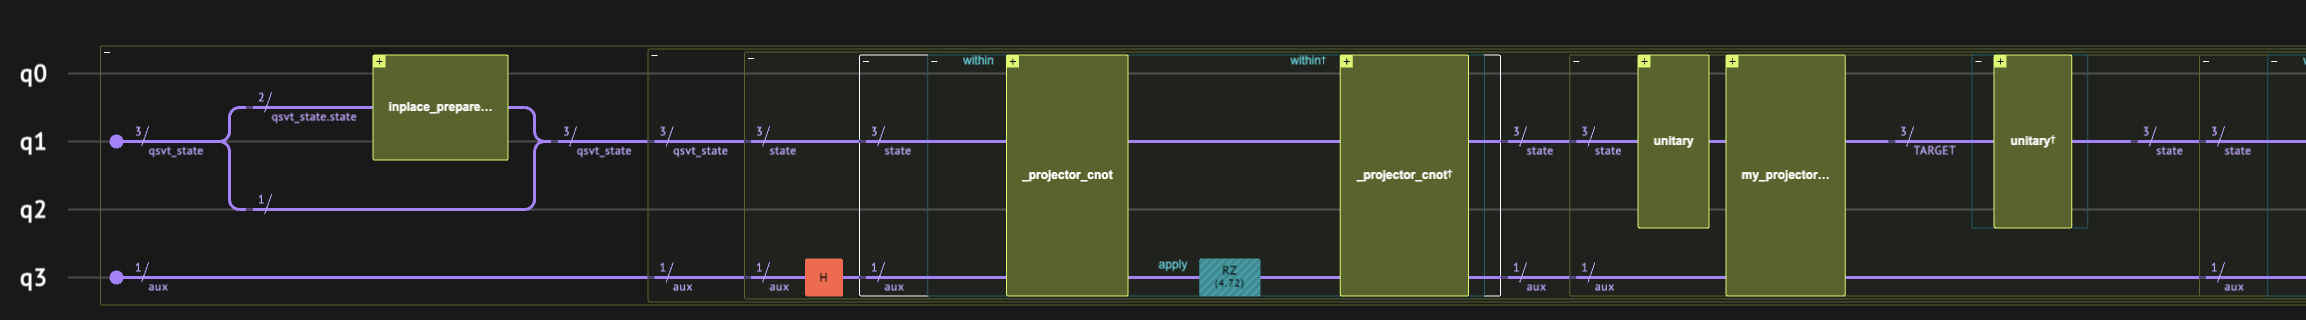

If our matrix $A$ is block-encoded with a block variable of size $m$, then the QSVT routine block encodes the inverse of $A$ on $m+1$ qubits, where the additional qubit is the QSVT auxiliary. Therefore, we need to post-select on `block` being zero, if we want to obtain a state $\sim A^{-1}|b\rangle$.

In [10]:
# Filter to block == all zeros (post-select on success)
zero_block = [0] * BLOCK_SIZE
df = result[result["block"].apply(lambda x: x == zero_block)].sort_values("data")
df

,data,block,amplitude,magnitude,phase,probability,bitstring
45,0,"[0, 0, 0, 0, 0]",-0.005721+0.028761j,0.03,0.56π,0.000860,0000000
2,1,"[0, 0, 0, 0, 0]",0.034919-0.175547j,0.18,-0.44π,0.032036,0000001
58,2,"[0, 0, 0, 0, 0]",0.002182-0.010968j,0.01,-0.44π,0.000125,0000010
7,3,"[0, 0, 0, 0, 0]",-0.021961+0.110407j,0.11,0.56π,0.012672,0000011


### Comparing to the Expected Result

Finally, we verify our quantum solution, by comparing it to the expected classical one.

In [11]:
expected_x = np.linalg.inv(A) @ b

The quantum routine returns,
$$
|x\rangle = \frac{1}{\alpha_{inv}}\left(A/s\right)^{-1} \frac{\vec{b}}{|\vec{b}|} |0\rangle_{\rm block} + \text{garbage},
$$

where $\alpha_{inv}$ is the scaling factor of the inverse block encoding (`be_inverse.alpha`). After post-selection (filtering) for the block qubits being zero, we have:
$$
\vec{x} = \frac{1}{\alpha_{inv}}\left(A/s\right)^{-1} \frac{\vec{b}}{|\vec{b}|}.
$$
We can now collect all the prefactors and compare to the expected result.

In [12]:
global_phase = np.angle(df.amplitude.iloc[0])
prefactor = b_norm * be_inverse.alpha
computed_x = prefactor * np.real(np.array(df.amplitude) / np.exp(1j * global_phase))

Let's compare it with the expected solution:

*Comment: even after removing the global phase to ensure a real solution, the quantum solution can be obtained up to a sign.*

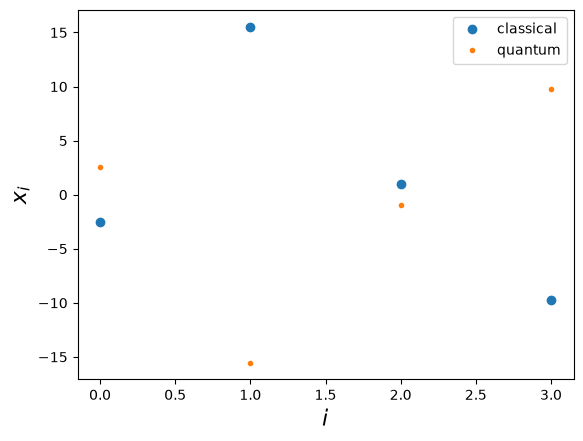

In [13]:
import matplotlib.pyplot as plt

plt.plot(expected_x, "o", label="classical")
plt.plot(computed_x, ".", label="quantum")
plt.xlabel(r"$i$", fontsize=16)
plt.ylabel(r"$x_i$", fontsize=16)
plt.legend();

In [14]:
assert (
    min(
        np.linalg.norm(computed_x - expected_x),
        np.linalg.norm(-computed_x - expected_x),
    )
    < 0.05
)

## References
<a id='ref-grand'>[1]</a>: [Martyn JM, Rossi ZM, Tan AK, Chuang IL. Grand unification of quantum algorithms. PRX Quantum 2, 040203. (2021).](https://journals.aps.org/prxquantum/abstract/10.1103/PRXQuantum.2.040203)

<a id='ref-childs'>[2]</a>: [A. M. Childs, R. Kothari, and R. D. Somma. Quantum algorithm for systems of linear equations with exponentially improved dependence on precision. SIAM Journal on Computing 46, 1920-1950 (2017).](https://arxiv.org/abs/1511.02306)

## A Note on Efficient Block-Encoding, Condition Number, and Complexity

An efficient block-encoding of a matrix $A$ means that the resources to construct the unitary $U_{A,s}$, as well as the scaling factor $s$, scales poly-logarithmically with the matrix dimension. This technical note concerns the latter point.

First, we note that an optimal value for the scaling factor $s$ is the maximal singular value $\sigma_{\max}$, namely $s\geq \sigma_{\max}$. This comes directly from the requirement that $||A/s||\leq 1$. For that reason, the effective condition number used throughout the demo, $\kappa = s/\sigma_{\min}$, is bounded from below by the actual condition number $\sigma_{\max}/\sigma_{\min}$.

Next, note that if $s$ scales linearly with the problem size, then the exponential speedup is lost. This is because the polynomial degree then scales as $O(N)$. In addition, the amplitude of the encoded solution scales the same (although it also depends on the input vector $|b\rangle$), which requires an additional amplitude amplification routine that adds a factor of $O(\sqrt{N})$ to the overall resources.
